<a href="https://colab.research.google.com/github/janetakhati-gif/Dancing/blob/main/Logistic_Regression_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Ad. Sale Prediction from Existing customer - Logistic Regression**

Logistic regression is the appropriate regression analysis to conduct when the dependent variable is dichotomous (binary). Like all regression analyses, it is a predictive analysis. It is used to describe data and to explain the relationship between one dependent binary variable and one or more nominal, ordinal, interval or ratio-level independent variables.

It just means a variable that has only 2 outputs, for example, A person will survive this accident or not, The student will pass this exam or not. The outcome can either be yes or no (2 outputs). This regression technique is similar to linear regression and can be used to predict the Probabilities for classification problems.

*Types of Logistic Regression*


**Binary Logistic Regression**

It is used to predict the probability of a binary outcome, such as yes or no, true or false, or 0 or 1. For example, it could be used to predict whether a customer will churn or not, whether a patient has a disease or not, or whether a loan will be repaid or not.

**Multinomial Logistic Regression**

Multinomial logistic regression is used to predict the probability of one of three or more possible outcomes, such as the type of product a customer will buy, the rating a customer will give a product, or the political party a person will vote for.

**Ordinal Logistic Regression**

It is used to predict the probability of an outcome that falls into a predetermined order, such as the level of customer satisfaction, the severity of a disease, or the stage of cancer

**Why do we use Logistic Regression rather than Linear Regression?**

After reading the definition ,we now know that it is only used when our dependent variable is binary and in linear regression this dependent variable is continuous.

The second problem is that if we add an outlier in our dataset, the best fit line in linear regression shifts to fit that point.

Now, if we use linear regression to find the best fit line which aims at minimizing the distance between the predicted value and actual value, the line will be like this:

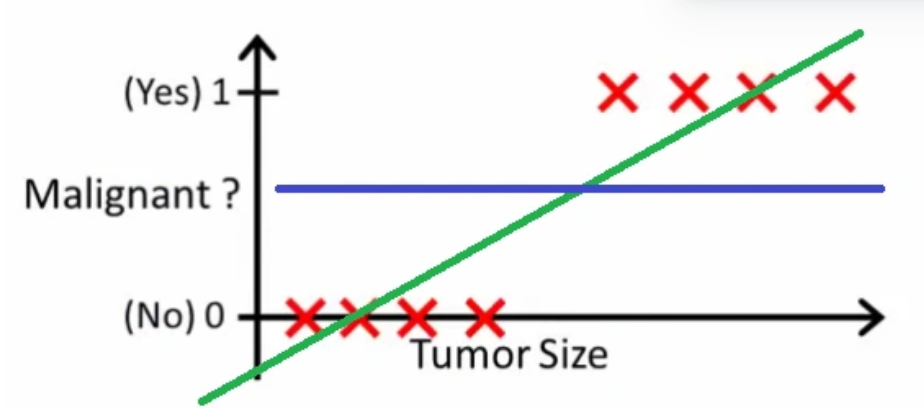

Here the threshold value is 0.5, which means if the value of h(x) is greater than 0.5 then we predict malignant tumor (1) and if it is less than 0.5 then we predict benign tumor (0). Everything seems okay here but now lets change it a bit, we add some outliers in our dataset, now this best fit line will shift to that point. Hence the line will be somewhat like this:

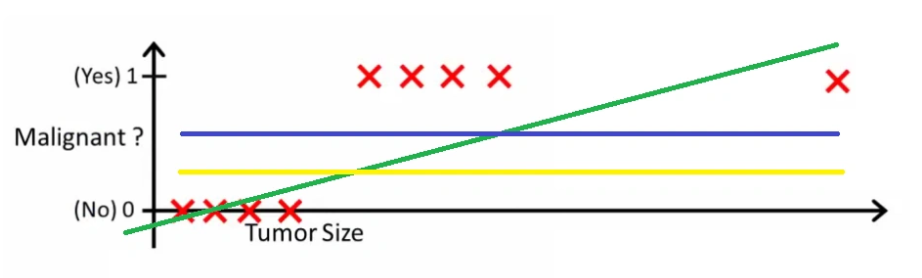


The blue line represents the old threshold, and the yellow line represents the new threshold, which is maybe 0.2. To keep our predictions right, we had to lower our threshold value. Hence, we can say that linear regression is prone to outliers. Now, if h(x)h(x)h(x) is greater than 0.2, only this regression will give correct outputs. Another problem with linear regression is that the predicted values may be out of range. We know that probability can be between 0 and 1, but if we use linear regression, this probability may exceed 1 or go below 0. To overcome these problems, we use Logistic Regression, which converts this straight best-fit line in linear regression to an S-curve using the sigmoid function, which will always give values between 0 and 1.


**Assumptions of logistic regression**

Logistic regression is a statistical method commonly used to analyze data with binary outcomes (yes/no, 1/0) and identify the relationship between those outcomes and independent variables. Here are some key assumptions for logistic regression:

1. Data Specific

Binary Dependent Variable: It is designed for binary dependent variables. If your outcome has more than two categories, you might need a multinomial logistic regression or other classification techniques.

Independent Observations: The data points should be independent of each other. This means no repeated measurements or clustering within the data.
Relationship Between Variables

2. Linearity in the Logit: The relationship between the independent variables and the logit of the dependent variable (ln(p / (1-p))) is assumed to be linear. This doesnt necessarily mean the outcome itself has a linear relationship with the independent variables, but the log-odds do.

3. No Multicollinearity: Independent variables shouldnt be highly correlated with each other. Multicollinearity can cause instability in the model and make it difficult to interpret the coefficients.

4. Absence of Outliers: While not a strict requirement, outliers can significantly influence the model. Its important to check for and address any outliers that might distort the results.

5. Adequate Sample Size: These are typically requires a reasonably large sample size to ensure reliable parameter estimates. There are different rules of thumb, but a common guideline is to have at least 10 observations for each independent variable in the model.pen_spark

In [ ]:
#IMPORTING LIBRARIES
import pandas as pd #useful for loading the dataset
import numpy as np #to perform array

In [ ]:
#Load the dataset
dataset = pd.read_csv('/content/DigitalAd_dataset (1).csv')

In [ ]:
#Summarize dataset
'''
When doing logistic regression you should:
 - check for missing values
 - check for outliers
 - check for inconsistencies in data
 - check if distribution of classes is balaced or not
'''
print(dataset.shape)
print(dataset.head(5))
print(dataset['Status'].unique())

(400, 3)
   Age  Salary  Status
0   18   82000       0
1   29   80000       0
2   47   25000       1
3   45   26000       1
4   46   28000       1
[0 1]


In [ ]:
#Segregate Dataset into X(Input/IndependentVariable) & Y(Output/DependentVariable)
X = dataset.drop('Status', axis=1)
X

,Age,Salary
0,18,82000
1,29,80000
2,47,25000
3,45,26000
4,46,28000
...,...,...
395,35,65000
396,26,80000
397,26,52000
398,20,86000


In [ ]:
Y = dataset.Status
Y

,Status
0,0
1,0
2,1
3,1
4,1
...,...
395,0
396,0
397,0
398,0


In [ ]:
#Splitting Dataset into Train & Test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25, random_state = 0)

**Feature Scaling**

- we scale our data to make all the features contribute equally to the result
- Fit_Transform - fit method is calculating the mean and variance of each of the features present in our data
- Transform - Transform method is transforming all the features using the respective mean and variance,
- We want our test data to be a completely new and a surprise set for our model

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
#Training
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state = 0)
model.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [ ]:
#Prediction for all Test Data
y_pred = model.predict(X_test)

print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.values.reshape(len(y_test),1)),1))

[[0 1]
 [0 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 1]
 [0 1]
 [1 1]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]]


### *Evaluating Model - CONFUSION MATRIX*
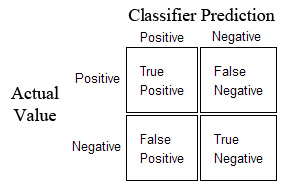

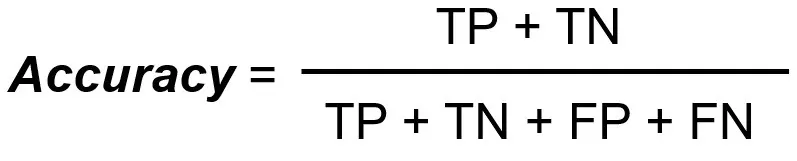

**Confusion Matrix derived metrics**

Each of these metrics answers a certain question :

- Accuracy:

How many Correct predictions we made out of all observations : Accuracy = (TP+TN)/(TP+FP+FN+TN)

- Recall / sensitivity / true positive rate (TPR):

How well the classifiers can detect the positive class : Recall = TP/(TP+FN)

- Precision:

How much you can trust your algorithm when it predicts “positive” : Precision= TP/(TP+FP)

- Specificity :

How well the classifier can detects the negative class: Specificity= TN/(TN+FP)

- False positive rate (FPR):
What fraction of all negative instances does the classifier incorrectly identify as positive: FPR = FP/(FP+TN)


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix: ")
print(cm)

print("Accuracy of the Model: {0}%".format(accuracy_score(y_test, y_pred)*100))

Confusion Matrix: 
[[61  0]
 [20 19]]
Accuracy of the Model: 80.0%



- True Positives (TP): 61 – These are the cases where the model correctly predicted that the customer would purchase the ad (positive class).
- True Negatives (TN): 19 – These are the cases where the model correctly predicted that the customer would not purchase the ad (negative class).
- False Positives (FP): 20 – These are the cases where the model incorrectly predicted that the customer would purchase the ad when they actually would not.
- False Negatives (FN): 0 – These are the cases where the model incorrectly predicted that the customer would not purchase the ad when they actually would.

**Interpretation of the Confusion Matrix:**

Accuracy: It shows that the model is doing a good job of predicting the customers who will not purchase the ad, with 61 correct positive predictions and 20 false positives. However, it misclassifies 19 potential buyers as non-buyers (true negatives), which means it missed some sales opportunities.

In [ ]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.75      1.00      0.86        61
           1       1.00      0.49      0.66        39

    accuracy                           0.80       100
   macro avg       0.88      0.74      0.76       100
weighted avg       0.85      0.80      0.78       100



- Recall (Sensitivity): The recall tells us how well the model is identifying customers who will buy the ad. It can be calculated as:

Recall = TP/(TP+FN) = 61/(61+0) = 1

This means the model is identifying only 100% of the actual ad buyers.

- Precision: Precision tells us how accurate the positive predictions are. It can be calculated as:

Precision = TP/(TP+FP) = 61/(61+20) =

- Accuracy:This metric tells us the proportion of correct predictions made by the model.

Formula: (TP+TN)/Total = (19+61)/100 = 0.80

Accuracy is high in cases where the model predicts the majority class well, but it may not be reliable in imbalanced datasets.


The model is perfect in predicting ad buyers who will actually buy.

In [ ]:
#Receiver Operating Curve - ROC Curve

No Skill: ROC AUC=50.000
Logistic Skill: ROC AUC=92.980


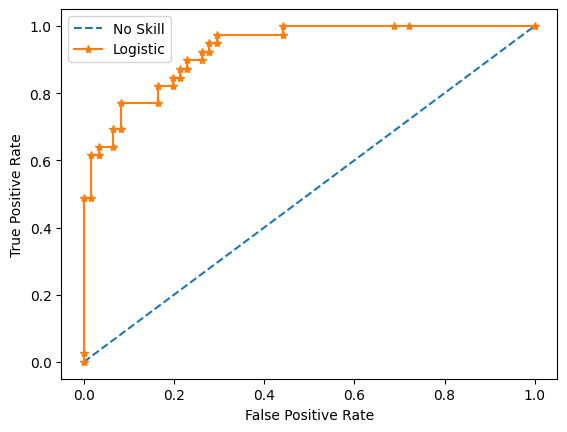

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

nsProbability = [0 for _ in range(len(y_test))]
lsProbability = model.predict_proba(X_test)
# keep probabilities for the positive outcome only
lsProbability = lsProbability[:, 1]
# calculate scores
nsAUC = roc_auc_score(y_test, nsProbability)
lrAUC = roc_auc_score(y_test, lsProbability)
# summarize scores
print('No Skill: ROC AUC=%.3f' % (nsAUC*100))
print('Logistic Skill: ROC AUC=%.3f' % (lrAUC*100))
# calculate roc curves
nsFP, nsTP, _ = roc_curve(y_test, nsProbability)
lrFP, lrTP, _ = roc_curve(y_test, lsProbability)
# plot the roc curve for the model
plt.plot(nsFP, nsTP, linestyle='--', label='No Skill')
plt.plot(lrFP, lrTP, marker='*', label='Logistic')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()
plt.show()

The ROC curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) for different classification thresholds. The area under this curve (AUC) indicates the model's ability to distinguish between positive and negative classes. A higher AUC suggests better model performance.

- AUC = 0.50: This represents a model with no discriminatory ability (random guessing).
- AUC = 1.00: This represents a perfect model.

In our case, the AUC = 92.98% for the Logistic Regression model suggests that it performs quite well, distinguishing between the positive and negative classes effectively. The higher the AUC, the better the model's ability to classify correctly across different thresholds.

Conclusion:

The logistic regression model shows a strong ability to distinguish between classes, with an AUC of 92.98%, far better than random guessing.

In [ ]:
#Cross Validation Score

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
kfold = KFold(n_splits=10, shuffle=True, random_state = 100)
result = cross_val_score(model, X, Y, cv=kfold)
print("CROSS VALIDATION SCORE: %.2f%%" % (result.mean()*100.0))

CROSS VALIDATION SCORE: 84.50%


The code uses KFold from sklearn.model_selection to split the data into 10 folds, shuffling the data before splitting using a random seed of 100.

The cross_val_score function is used to calculate the accuracy of the model over these 10 folds.

In [ ]:
#Stratifield K-fold Cross Validation
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
skfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=100)
model_skfold = LogisticRegression()
results_skfold = cross_val_score(model_skfold, X, Y, cv=skfold)
print("STRATIFIELD K-FOLD SCORE: %.2f%%" % (results_skfold.mean()*100.0))

STRATIFIELD K-FOLD SCORE: 84.49%


The code uses StratifiedKFold to split the data into 3 folds, ensuring that the distribution of the target class is preserved in each fold.

cross_val_score is again used to calculate the accuracy of the Logistic Regression model over these 3 folds.

The scores are quite close, with 84.50% for K-fold and 84.49% for Stratified K-fold, suggesting that the class distribution has little impact on the model's performance in this case.

100
39


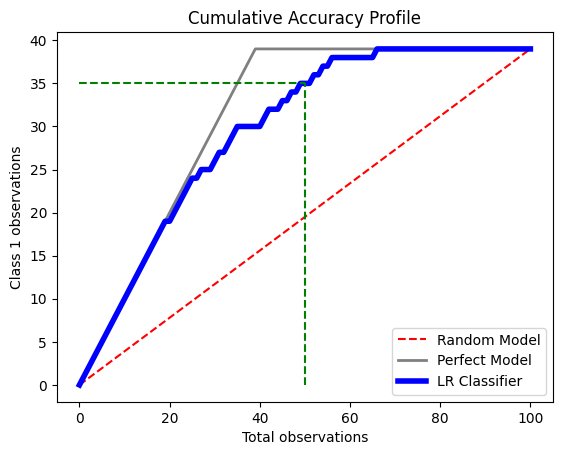

In [ ]:
#Cumulative Accuracy Profile (CAP) Curve
total = len(y_test)
print(total)
class_1_count = np.sum(y_test)
print(class_1_count)
class_0_count = total - class_1_count
plt.plot([0, total], [0, class_1_count], c = 'r', linestyle = '--', label = 'Random Model')

plt.plot([0, class_1_count, total],
         [0, class_1_count, class_1_count],
         c = 'grey',
         linewidth = 2,
         label = 'Perfect Model')

probs = model.predict_proba(X_test)
probs = probs[:, 1]
model_y = [y for _, y in sorted(zip(probs, y_test), reverse = True)]
y_values = np.append([0], np.cumsum(model_y))
x_values = np.arange(0, total + 1)

plt.plot(x_values,
         y_values,
         c = 'b',
         label = 'LR Classifier',
         linewidth = 4)

index = int((50*total / 100))

## 50% Verticcal line from x-axis
plt.plot([index, index], [0, y_values[index]], c ='g', linestyle = '--')

## Horizontal line to y-axis from prediction model
plt.plot([0, index], [y_values[index], y_values[index]], c = 'g', linestyle = '--')

class_1_observed = y_values[index] * 100 / max(y_values)
plt.xlabel('Total observations')
plt.ylabel('Class 1 observations')
plt.title('Cumulative Accuracy Profile')
plt.legend(loc = 'lower right')

CAP curve is used to evaluate how effectively a classification model can identify all relevant data points in the given class with the fewest attempts.

It helps assess the model’s robustness and is analyzed using the area under the curve or by plotting the CAP analysis.

**Interpretation of the CAP Curve:**

- The y-axis shows the number of correctly predicted positive instances (Class 1 observations).
- The x-axis shows the total number of observations considered.

In this case:

- The blue line shows that the Logistic Regression model correctly identifies a significant number of positive cases with fewer observations, outperforming the random model (dashed red line).
- The green dashed vertical line likely marks the point where the classifier achieves a certain level of correctness, showing how many total observations are needed to achieve a certain number of correct positive predictions.

**Predicting, wheather new customer with Age & Salary will Buy or Not**

In [ ]:
age = int(input("Enter New Customer Age: "))
sal = int(input("Enter New Customer Salary: "))
newCust = [[age,sal]]
result = model.predict(sc.transform(newCust))
print(result)
if result == 1:
  print("Customer will Buy")
else:
  print("Customer won't Buy")

Enter New Customer Age: 15
Enter New Customer Salary: 17000
[0]
Customer won't Buy


In [ ]:
Logistic Regression Data Preparation
use this data.csv
# Import necessary libraries
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Load the data
data = pd.read_csv('/content/Data.csv')

#preparing data for logistic regression

data["admitted"]=data["admitted"].map({"yes": 1, "no": 0})   #convert admitted variable into numerical

data.head()

# Logistic Regression Code
#import relevant libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
#features extraction
x = data[['gmat', 'gpa','work_experience']]
y = data['admitted']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)
#splitting data with test size of 25%
logreg = LogisticRegression()   #build our logistic model
logreg.fit(x_train, y_train)  #fitting training data
y_pred  = logreg.predict(x_test)    #testing model’s performance
print("Accuracy={:.2f}".format(logreg.score(x_test, y_test)))
Logistic Regression Distribution
import seaborn as sns
sns.regplot(x='gmat',y='admitted',data=data)


# If p >= 0.5, then the candidate is getting admitted. If p < 0.5, then the candidate is not getting admit